In [163]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [165]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.nn.functional as F
import os
import random
import pandas as pd
import torch.optim as optim
from tqdm import tqdm
#from torch.optim.lr_scheduler import 


from src.psd.psd import calculate_psd
from src.data.dataloader import generate_data
from src.utils import seed_cpu
from src.dataset.particledataset import PulseData
from src.model.model import PulseVAE
from src.loss import vae_loss_function
from src.train import Trainer 

In [166]:
# fix seed
seed_cpu(42)

### Загрузка данных

In [167]:
X, y, amplitudes = generate_data(
    number_of_samples=20000,
    amp_range=(2, 40),
    length=200,
    noise_std=1
)

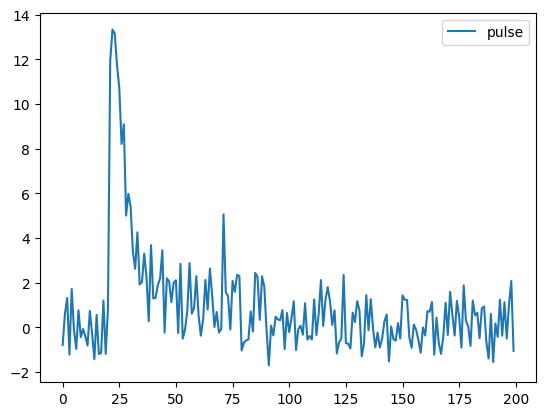

In [168]:
plt.plot(X[0], label='pulse')
plt.legend()
plt.show()

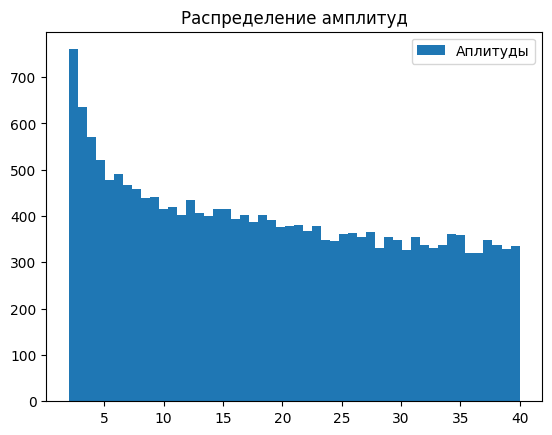

In [169]:
plt.hist(amplitudes, bins=50, label='Аплитуды')
plt.title('Распределение амплитуд')
plt.legend()
plt.show()

### Датасет

In [170]:
X_train, X_test, y_train, y_test, amplitudes_train, amplitudes_test = train_test_split(
    X, y, amplitudes,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [171]:
train_dataset = PulseData(X_train, y_train, amplitudes_train)
test_dataset = PulseData(X_test, y_test, amplitudes_test)

In [172]:
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False)

### Модель

In [173]:
model = PulseVAE(latent_dim=1, out_channels_first=10)

optimizer = optim.Adam(model.parameters(), lr=0.001)


In [174]:
num_epochs = 30
history_of_learn = {"train_loss_array": [],
                    "test_loss_array": []}
best_test_loss = float('inf')

In [175]:
trainer = Trainer(
    model=model,
    criterion=vae_loss_function,
    optimizer=optimizer,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    num_epochs=num_epochs,
    warmup_beta=15,
    max_beta=5e-4
)

In [176]:
history_of_learn = trainer.fit()

Epoch -> 1/30


100%|██████████| 63/63 [00:00<00:00, 176.28it/s]


TRAIN loss-> 0.015708853278309107
TEST loss -> 0.012299400562095263
Epoch -> 2/30


100%|██████████| 63/63 [00:00<00:00, 150.17it/s]


TRAIN loss-> 0.01237224697880447
TEST loss -> 0.01220798147990117
Epoch -> 3/30


...

TRAIN loss-> 0.012551150405779482
TEST loss -> 0.012350243612355183
Epoch -> 29/30


100%|██████████| 63/63 [00:00<00:00, 171.77it/s]


TRAIN loss-> 0.012556298077106476
TEST loss -> 0.012352768435246415
Epoch -> 30/30


100%|██████████| 63/63 [00:00<00:00, 172.00it/s]

TRAIN loss-> 0.012555813686922192
TEST loss -> 0.012343686421416582


In [219]:
model.load_state_dict(torch.load("checkpoints/best_vae_model.pth", weights_only=True))

<All keys matched successfully>

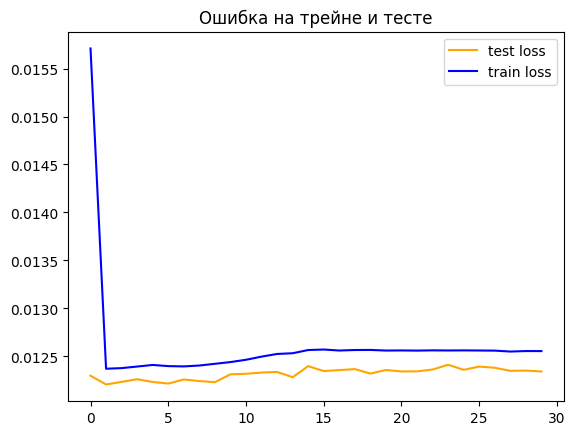

In [220]:
plt.plot(history_of_learn['test_loss'], color='orange', label='test loss')
plt.plot(history_of_learn['train_loss'], color='blue', label='train loss')
plt.title('Ошибка на трейне и тесте')
plt.legend()
plt.show()

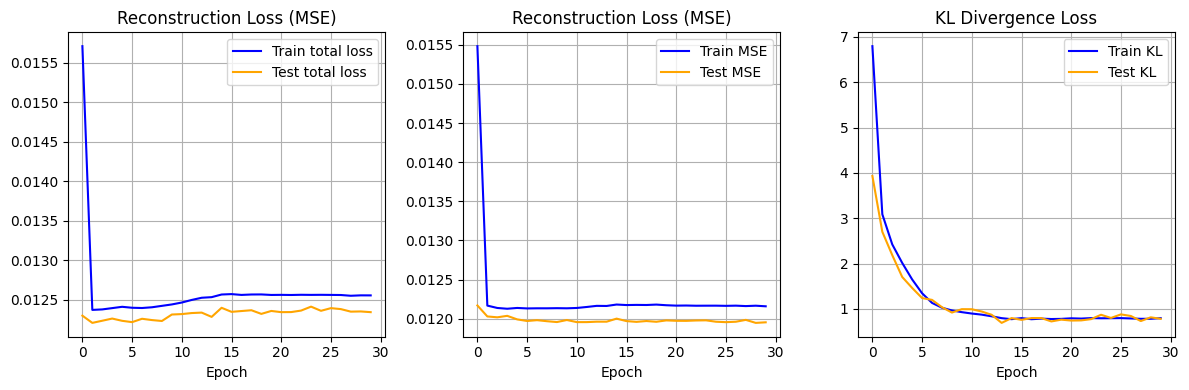

In [221]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# 1. Reconstruction Loss (насколько точно восстанавливается форма импульса)
plt.subplot(1, 3, 2)
plt.plot(history_of_learn['train_recon_loss'], label='Train MSE', color='blue')
plt.plot(history_of_learn['test_recon_loss'], label='Test MSE', color='orange')
plt.title('Reconstruction Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)

# 2. KL Loss (структурирование латентного пространства)

plt.subplot(1, 3, 3)
plt.plot(history_of_learn['train_kl_loss'], label='Train KL', color='blue')
plt.plot(history_of_learn['test_kl_loss'], label='Test KL', color='orange')
plt.title('KL Divergence Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)


plt.subplot(1, 3, 1)
plt.plot(history_of_learn['train_loss'], label='Train total loss', color='blue')
plt.plot(history_of_learn['test_loss'], label='Test total loss', color='orange')
plt.title('Reconstruction Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [222]:
data = pd.DataFrame(columns=['latent_vectors', 'whole_energy', 'psd', 'type'])

In [223]:
X_test_norm = X_test / np.max(X_test, axis=1).reshape(-1,1)

In [224]:
model.eval()
with torch.no_grad():
    outputs, mu, logvar = model(torch.tensor(X_test_norm, dtype=torch.float32))

In [225]:
outputs.shape

torch.Size([4000, 1, 200])

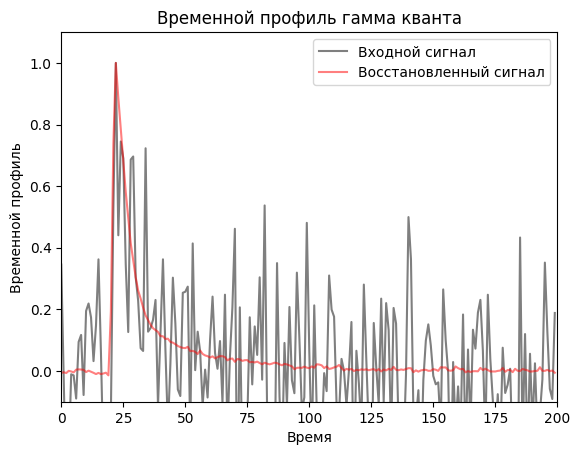

In [226]:
plt.plot(X_test[0] / np.max(X_test[0]), color='black', alpha=0.5, label='Входной сигнал')
plt.plot(outputs.numpy()[0].reshape(-1), color='red', alpha=0.5, label='Восстановленный сигнал')
plt.legend()
plt.title("Временной профиль гамма кванта")
plt.ylabel("Временной профиль")
plt.xlabel("Время")
plt.xlim(0, 200.0)
plt.ylim(-0.1, 1.1)
plt.show()

In [227]:
data = pd.DataFrame(columns=['latent_vectors', 'whole_energy', 'psd', 'type'])

In [228]:
data['latent_vectors'] = list(mu.numpy())
data['whole_energy'], data['psd'] = calculate_psd(X_test, tail_time=30, start_time=20)
data['type'] = y_test

In [229]:
from sklearn.metrics import accuracy_score

In [230]:
threshold = 0.57 
data['preds_psd_type'] = (data['psd'] < threshold).astype(int)

In [231]:
data.head()

,latent_vectors,whole_energy,psd,type,preds_psd_type
0,[1.4050888],28.358079,0.138880,1.0,1
1,[-0.96837145],535.748013,0.629603,0.0,0
2,[-0.90095097],295.440157,0.638220,0.0,0
3,[0.77863604],197.101136,0.493032,1.0,1
4,[-0.9151456],519.659078,0.632540,0.0,0


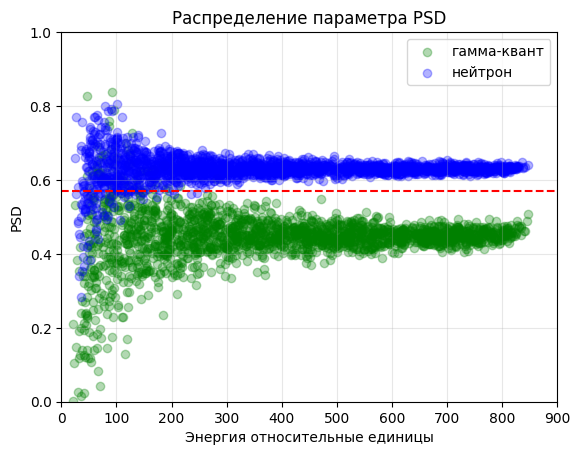

In [232]:
factor = data[data['type'] == 0]['whole_energy'].max() / data[data['type'] == 1]['whole_energy'].max()
plt.scatter(data[data['type'] == 1]['whole_energy'] * factor, data[data['type'] == 1]['psd'], color='green', alpha=0.3, label='гамма-квант')
plt.scatter(data[data['type'] == 0]['whole_energy'], data[data['type'] == 0]['psd'], color='blue', alpha=0.3,  label='нейтрон')
plt.axhline(0.57, linestyle='--', color='red')
plt.title('Распределение параметра PSD')
plt.xlim(0, 900)
plt.ylim(0, 1)
plt.legend()

plt.grid(alpha=0.3)
plt.ylabel('PSD')
plt.xlabel('Энергия относительные единицы')
plt.show()

In [233]:
data

,latent_vectors,whole_energy,psd,type,preds_psd_type
0,[1.4050888],28.358079,0.138880,1.0,1
1,[-0.96837145],535.748013,0.629603,0.0,0
2,[-0.90095097],295.440157,0.638220,0.0,0
3,[0.77863604],197.101136,0.493032,1.0,1
4,[-0.9151456],519.659078,0.632540,0.0,0
...,...,...,...,...,...
3995,[0.71395195],299.968943,0.482676,1.0,1
3996,[0.82592577],121.067087,0.425002,1.0,1
3997,[0.77661663],85.857620,0.381989,1.0,1
3998,[0.8962957],96.782187,0.354861,1.0,1


In [234]:
accuracy = accuracy_score(data['type'], data['preds_psd_type'])
print(f"Accuracy score {accuracy}")

Accuracy score 0.966


In [235]:
first_latent_0 = np.vstack(data[data['type'] == 0]['latent_vectors'].values)[:, 0]
first_latent_1 = np.vstack(data[data['type'] == 1]['latent_vectors'].values)[:, 0]

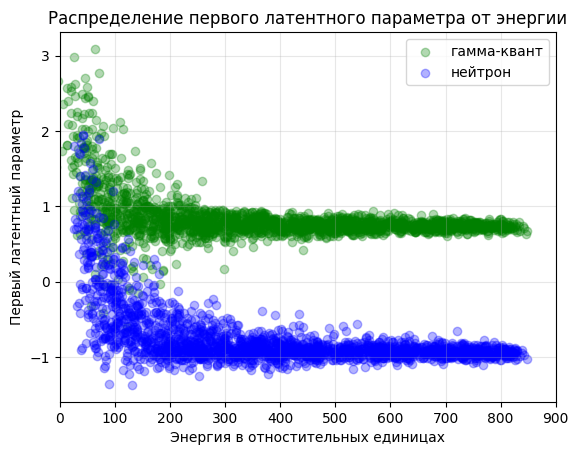

In [236]:

plt.scatter(data[data['type'] == 1]['whole_energy'] * factor, first_latent_1, color='green', alpha=0.3, label='гамма-квант')
plt.scatter(data[data['type'] == 0]['whole_energy'], first_latent_0, color='blue', alpha=0.3, label='нейтрон')
plt.title("Распределение первого латентного параметра от энергии")
plt.legend()
plt.ylabel("Первый латентный параметр")
plt.xlabel('Энергия в отностительных единицах')
plt.grid(alpha=0.3)
plt.xlim(0, 900)
plt.show()

In [237]:
from sklearn.cluster import KMeans


In [238]:
X_latent = np.vstack(data['latent_vectors'].values)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
predicted_labels = kmeans.fit_predict(X_latent)

if accuracy_score(data['type'], predicted_labels) < 0.5:
    predicted_labels = 1 - predicted_labels

data['preds_kmeans_type'] = predicted_labels

In [239]:
print(f"Accuracy score KMeans {accuracy_score(data['type'], data['preds_kmeans_type'])}")

Accuracy score KMeans 0.965


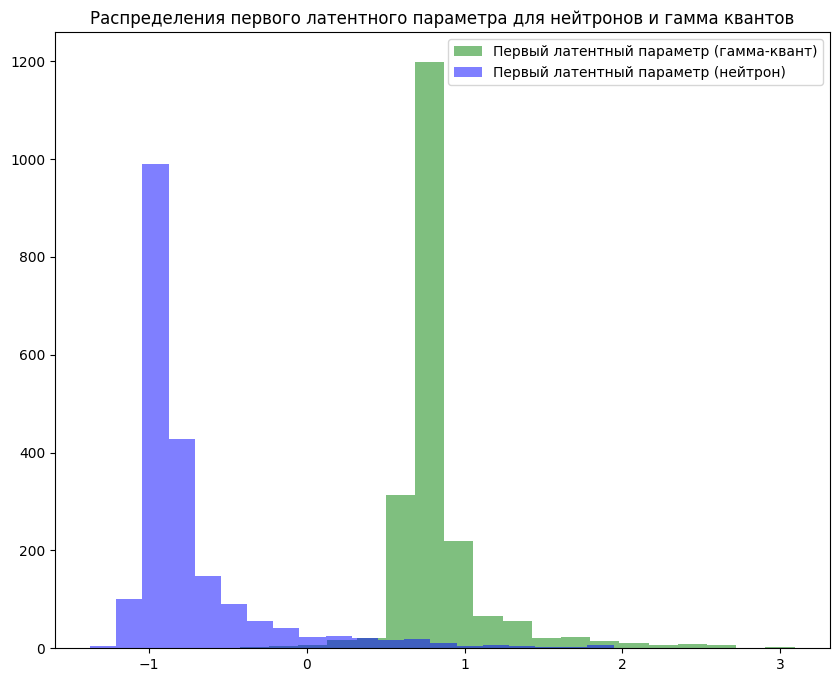

In [240]:
plt.figure(figsize=(10, 8))
plt.hist(X_latent[y_test == 1][:, 0], color='green', label='Первый латентный параметр (гамма-квант)', alpha=0.5, bins=20)
plt.hist(X_latent[y_test == 0][:, 0], color='blue', label='Первый латентный параметр (нейтрон)', alpha=0.5, bins=20)
plt.title('Распределения первого латентного параметра для нейтронов и гамма квантов')
plt.legend()
plt.show()
